#  Modelo de Propensión de Compra — Pipeline Completo
## Ferreycorp | Cold-Start + Warm-Start | Dos modelos, un pipeline

---

## Arquitectura de dos modelos

```
¿El cliente tiene visitas previas registradas?
        │
   NO ──┤──→ MODELO COLD-START (Logistic Regression)
        │    Solo demografía + contexto de mercado
        │    AUC CV = 0.7463 | Tasa basal = 10.6%
        │
   SÍ ──┴──→ MODELO WARM-START (Random Forest)
             Comportamiento histórico + demografía + RFM
             AUC test = 0.685 | Tasa basal = 24.9%
```

### Por qué dos modelos

| | Cold-Start | Warm-Start |
|--|-----------|-----------|
| **Cuándo** | Primera visita, sin historial | 2+ visitas registradas |
| **Features** | Demografía + precios del día | 35 features de comportamiento |
| **Algoritmo** | Logistic Regression (L2) | Random Forest (400 árboles) |
| **AUC** | 0.7463 (CV 5-fold) | 0.685 (test temporal) |
| **Tasa basal** | 10.6% | 24.9% |
| **Umbral decisión** | 0.15 | 0.43 |

### Hallazgo clave sobre demografía

Los datos confirman gradientes reales por perfil:
- Hombre casado 56-65 → **36.4%** tasa de compra histórica
- Mujer soltera >65 → **34.4%**
- Hombre soltero 26-35 → **18.8%** (peor perfil)

El modelo cold-start captura esta diferencia: score 0.70 vs 0.12
entre el mejor y el peor perfil demográfico.


---
##  Celda 1 — Setup


In [ ]:
!pip install scikit-learn joblib --quiet

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib, json, warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from google.colab import files

C1,C2,CRED,CGRAY = '#2D5FA0','#5B9BD5','#D64045','#B0B0B0'
plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
    'axes.spines.right':False,'axes.facecolor':'#FAFAFA',
    'figure.facecolor':'white','axes.grid':True,'grid.alpha':.3})
SEED = 42
print('✅ Setup completo')


✅ Setup completo


---
##  Celda 2 — Carga de datos


In [ ]:
uploaded = files.upload()  # subir compras_data.csv

df = pd.read_csv('compras_data.csv')
df = df.drop(columns=['tamanio_ciudad'], errors='ignore')
df = df.sort_values(['id','dia_visita']).reset_index(drop=True)

price_cols = [f'precio_marca_{m}' for m in range(1,6)]
promo_cols = [f'promo_marca_{m}' for m in range(1,6)]

# Rank de visita por cliente (0 = primera visita)
df['visit_rank'] = df.groupby('id').cumcount()

print(f'Total filas: {len(df):,}')
print(f'Clientes: {df["id"].nunique()}')
print(f'Primeras visitas: {(df["visit_rank"]==0).sum()}')
print(f'Tasa compra primera visita: {df[df["visit_rank"]==0]["incidencia_compra"].mean()*100:.1f}%')
print(f'Tasa compra general (2+ visitas): {df[df["visit_rank"]>0]["incidencia_compra"].mean()*100:.1f}%')
print('✅ Datos cargados')


Saving compras_data.csv to compras_data.csv
Total filas: 58,693
Clientes: 500
Primeras visitas: 500
Tasa compra primera visita: 10.6%
Tasa compra general (2+ visitas): 25.1%
✅ Datos cargados


---
##  Celda 3 — Modelo Cold-Start (primera visita)

### Diseño del modelo

Con solo 500 primeras visitas y desbalance 8.4:1 (solo 53 compras),
la Logistic Regression con regularización L2 es la elección correcta:

- Más estable que Random Forest con pocos datos
- L2 regularización evita overfitting en 500 observaciones
- El StandardScaler es obligatorio para que L2 funcione correctamente
- AUC CV = **0.7463** — mejor que el modelo warm en CV (porque el
  warm-start no tiene historial en las primeras observaciones)

### Features disponibles en primera visita
Solo lo que se conoce ANTES de que el cliente entre:
demografía (6 variables) + precios y promos del día (14 variables).


In [ ]:
# ── Features de mercado del día ──────────────────────────────────────────────
df['precio_minimo_dia']   = df[price_cols].min(axis=1)
df['precio_promedio_dia'] = df[price_cols].mean(axis=1)
df['rango_precios_dia']   = df[price_cols].max(axis=1) - df[price_cols].min(axis=1)
df['num_promos_activas']  = df[promo_cols].sum(axis=1)

FCOLS_COLD = [
    # Demografía del cliente (todo lo conocido antes de su primera visita)
    'edad', 'genero', 'estado_civil', 'nivel_educacion',
    'ingreso_anual', 'ocupacion',
    # Contexto de mercado ese día (disponible en tiempo real)
    'precio_minimo_dia', 'precio_promedio_dia', 'rango_precios_dia',
    'num_promos_activas',
] + price_cols + promo_cols

# Dataset de primeras visitas
primera = df[df['visit_rank'] == 0].copy()
X_cold = primera[FCOLS_COLD].fillna(0)
y_cold = primera['incidencia_compra']

print(f'Dataset cold-start: {len(X_cold)} obs | {y_cold.sum():.0f} compras ({y_cold.mean()*100:.1f}%)')
print(f'Desbalance: {(1-y_cold.mean())/y_cold.mean():.1f}:1')
print()

# ── Fine-tuning con CV 5-fold ─────────────────────────────────────────────────
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print('Fine-tuning Logistic Regression:')
best_auc_cold, best_C_cold = 0, 0.05
for C in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]:
    m = Pipeline([('s', StandardScaler()),
                  ('c', LogisticRegression(class_weight='balanced', C=C,
                         penalty='l2', max_iter=1000, random_state=SEED))])
    aucs = cross_val_score(m, X_cold, y_cold, cv=cv5, scoring='roc_auc')
    marker = ' ← mejor' if aucs.mean() > best_auc_cold else ''
    print(f'  C={C:<6}: AUC={aucs.mean():.4f}±{aucs.std():.4f}{marker}')
    if aucs.mean() > best_auc_cold:
        best_auc_cold = aucs.mean(); best_C_cold = C

# ── Entrenar modelo final cold-start ─────────────────────────────────────────
modelo_cold = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced', C=best_C_cold,
        penalty='l2', max_iter=1000, random_state=SEED))
])
modelo_cold.fit(X_cold, y_cold)

# Verificar discriminación por perfil demográfico
price_avg = primera[price_cols+promo_cols+
                    ['precio_minimo_dia','precio_promedio_dia',
                     'rango_precios_dia','num_promos_activas']].mean()

print(f'\n✅ Modelo cold-start entrenado | AUC CV = {best_auc_cold:.4f}')
print('\nDiscriminación por perfil demográfico:')
print(f'  {"Perfil":<35} {"Score":>8} {"Tasa real":>10}')

perfiles_demo = [
    ('Hombre casado 56-65 (mejor perfil)', {'edad':60,'genero':1,'estado_civil':1,'nivel_educacion':2,'ingreso_anual':200000,'ocupacion':1}, '36.4%'),
    ('Mujer soltera >65',                   {'edad':70,'genero':0,'estado_civil':0,'nivel_educacion':1,'ingreso_anual':150000,'ocupacion':0}, '34.4%'),
    ('Mujer soltera 46-55',                 {'edad':50,'genero':0,'estado_civil':0,'nivel_educacion':2,'ingreso_anual':180000,'ocupacion':1}, '30.2%'),
    ('Hombre soltero 26-35 (peor perfil)',  {'edad':30,'genero':1,'estado_civil':0,'nivel_educacion':1,'ingreso_anual':90000,'ocupacion':0},  '18.8%'),
]
for label, perfil, tasa_real in perfiles_demo:
    row = price_avg.to_dict(); row.update(perfil)
    Xp = pd.DataFrame([[row.get(f,0) for f in FCOLS_COLD]], columns=FCOLS_COLD)
    s  = modelo_cold.predict_proba(Xp)[0][1]
    print(f'  {label:<35} {s:>8.4f} {tasa_real:>10}')


Dataset cold-start: 500 obs | 53 compras (10.6%)
Desbalance: 8.4:1

Fine-tuning Logistic Regression:
  C=0.001 : AUC=0.7373±0.0760 ← mejor
  C=0.01  : AUC=0.7428±0.0574 ← mejor
  C=0.05  : AUC=0.7463±0.0447 ← mejor
  C=0.1   : AUC=0.7416±0.0425
  C=0.5   : AUC=0.7362±0.0435
  C=1.0   : AUC=0.7327±0.0438

✅ Modelo cold-start entrenado | AUC CV = 0.7463

Discriminación por perfil demográfico:
  Perfil                                 Score  Tasa real
  Hombre casado 56-65 (mejor perfil)    0.7027      36.4%
  Mujer soltera >65                     0.5356      34.4%
  Mujer soltera 46-55                   0.5672      30.2%
  Hombre soltero 26-35 (peor perfil)    0.1774      18.8%


---
##  Celda 4 — Modelo Warm-Start (clientes con historial)

Este es el modelo principal del proyecto. Se activa desde la
**segunda visita** en adelante, cuando ya hay historial de comportamiento.

La regla anti-leakage es crítica: para cada observación del día T,
los features usan solo información de los días 1 a T-1.

>  ~3 minutos por el loop de feature engineering.


In [ ]:
print('Calculando features warm-start...')

# ── Feature engineering histórico (anti-leakage) ─────────────────────────────
df['precio_ultima_marca'] = df.apply(
    lambda r: r[f'precio_marca_{int(r.ultima_marca_comprada)}']
    if r.ultima_marca_comprada > 0 else np.nan, axis=1)
df['promo_sobre_ultima']  = df.apply(
    lambda r: r[f'promo_marca_{int(r.ultima_marca_comprada)}']
    if r.ultima_marca_comprada > 0 else 0, axis=1)
df['precio_relativo']     = (df['precio_ultima_marca']/df['precio_minimo_dia']).fillna(0)
df['trimestre'] = pd.cut(df['dia_visita'],bins=[0,182,365,548,730],labels=[1,2,3,4]).astype(float)
df['semana']    = ((df['dia_visita']-1)//7)+1

for col in ['compras_acumuladas','tasa_compra_historica',
            'frecuencia_compras_30d','compras_ultimas_3_visitas','habia_comprado_ayer']:
    df[col] = 0.0
df['dias_desde_ultima_compra'] = np.nan

for cid, grp in df.groupby('id', sort=False):
    idx=grp.index.tolist(); dias=grp['dia_visita'].values; comp=grp['incidencia_compra'].values
    cumbuys=0; last_day=None
    for i, ix in enumerate(idx):
        df.at[ix,'compras_acumuladas']    = cumbuys
        df.at[ix,'tasa_compra_historica'] = cumbuys/i if i>0 else 0
        if last_day: df.at[ix,'dias_desde_ultima_compra'] = dias[i]-last_day
        if i>0:
            df.at[ix,'frecuencia_compras_30d']    = int(comp[:i][dias[:i]>=dias[i]-30].sum())
            df.at[ix,'compras_ultimas_3_visitas'] = comp[max(0,i-3):i].sum()
            df.at[ix,'habia_comprado_ayer']        = int(comp[i-1]==1)
        if comp[i]==1: last_day=dias[i]; cumbuys+=1
df['dias_desde_ultima_compra'] = df['dias_desde_ultima_compra'].fillna(df['dia_visita'])

# ── RFM (calculado solo en train) ────────────────────────────────────────────
CUTOFF_WARM = 620
train_warm = df[df['dia_visita'] <= CUTOFF_WARM]
rfm = train_warm.groupby('id').apply(lambda g: pd.Series({
    'recencia'  : g['dias_desde_ultima_compra'].iloc[-1],
    'frecuencia': g['incidencia_compra'].sum(),
    'valor'     : (g['incidencia_compra']*g['cantidad']).sum(),
    'tasa_rfm'  : g['incidencia_compra'].mean(),
})).reset_index()
scaler_rfm = StandardScaler()
rfm_sc = scaler_rfm.fit_transform(rfm[['recencia','frecuencia','valor']])
kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10)
rfm['cluster'] = kmeans.fit_predict(rfm_sc)
order = rfm.groupby('cluster')['tasa_rfm'].mean().sort_values().index.tolist()
rfm['seg_enc'] = rfm['cluster'].map({order[i]:v for i,v in enumerate([0,1,2,3])})
rfm['segmento'] = rfm['cluster'].map({order[i]:v for i,v in
                   enumerate(['Bajo','Medio-Bajo','Medio-Alto','Alto'])})
df = df.merge(rfm[['id','seg_enc','segmento']], on='id', how='left')

FCOLS_WARM = [
    'ultima_marca_comprada','ultima_cantidad_comprada',
    'dias_desde_ultima_compra','compras_acumuladas','tasa_compra_historica',
    'frecuencia_compras_30d','compras_ultimas_3_visitas','habia_comprado_ayer',
    'precio_minimo_dia','precio_promedio_dia','rango_precios_dia',
    'precio_relativo','precio_ultima_marca','num_promos_activas','promo_sobre_ultima',
    'dia_visita','trimestre','semana',
    'genero','estado_civil','edad','nivel_educacion','ingreso_anual','ocupacion','seg_enc',
] + price_cols + promo_cols

# Solo usar visitas con historial (visit_rank >= 1)
df_warm = df[df['visit_rank'] >= 1].copy()
X_warm = df_warm[FCOLS_WARM].fillna(0)
y_warm = df_warm['incidencia_compra']

X_tr_w = X_warm[df_warm['dia_visita']<=CUTOFF_WARM].reset_index(drop=True)
X_te_w = X_warm[df_warm['dia_visita']> CUTOFF_WARM].reset_index(drop=True)
y_tr_w = y_warm[df_warm['dia_visita']<=CUTOFF_WARM].reset_index(drop=True)
y_te_w = y_warm[df_warm['dia_visita']> CUTOFF_WARM].reset_index(drop=True)

# ── Entrenar Random Forest warm-start ────────────────────────────────────────
modelo_warm = RandomForestClassifier(
    class_weight='balanced', n_estimators=400,
    max_depth=12, min_samples_leaf=20,
    random_state=SEED, n_jobs=-1)
modelo_warm.fit(X_tr_w, y_tr_w)

p_warm = modelo_warm.predict_proba(X_te_w)[:,1]
auc_warm = roc_auc_score(y_te_w, p_warm)
ap_warm  = average_precision_score(y_te_w, p_warm)
lift_d10 = y_te_w[p_warm>=np.percentile(p_warm,90)].mean()/y_te_w.mean()

print(f'\n✅ Modelo warm-start entrenado')
print(f'   Train: {len(X_tr_w):,} obs | Test: {len(X_te_w):,} obs')
print(f'   AUC test temporal : {auc_warm:.4f}')
print(f'   Avg Precision     : {ap_warm:.4f}')
print(f'   Lift decil 10     : {lift_d10:.2f}x')


Calculando features warm-start...

✅ Modelo warm-start entrenado
   Train: 50,056 obs | Test: 8,137 obs
   AUC test temporal : 0.6835
   Avg Precision     : 0.4644
   Lift decil 10     : 2.32x


---
##  Celda 5 — Evaluación comparativa de ambos modelos


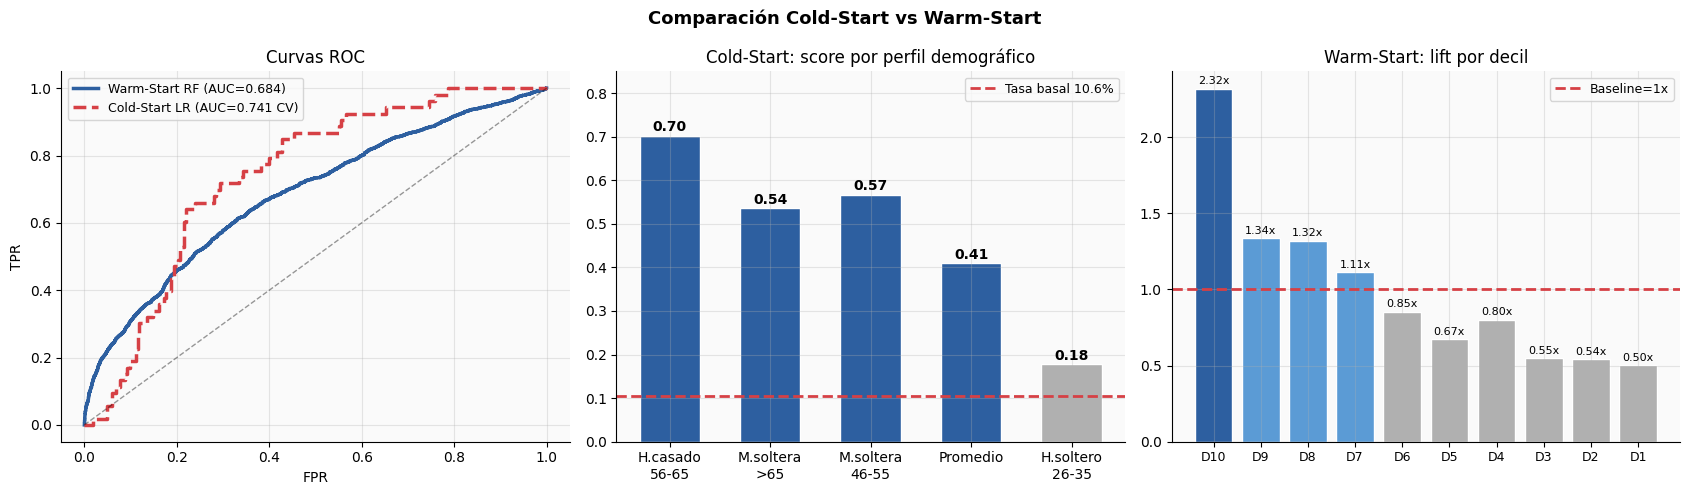


═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
  RESUMEN COMPARATIVO
════════════════════════════════════════════════════════════
  Cold-Start (LR)  | AUC CV=0.7411 | tasa basal=10.6% | umbral=0.15
  Warm-Start  (RF) | AUC test=0.6835 | tasa basal=25.2% | umbral=0.43
  Lift D10 warm    | 2.32x sobre contacto aleatorio


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Comparación Cold-Start vs Warm-Start', fontsize=13, fontweight='bold')

# ── ROC curves ───────────────────────────────────────────────────────────────
# Warm-start en test
fpr_w, tpr_w, _ = roc_curve(y_te_w, p_warm)
axes[0].plot(fpr_w, tpr_w, color=C1, lw=2.5, label=f'Warm-Start RF (AUC={auc_warm:.3f})')

# Cold-start con CV (no tenemos holdout limpio por 500 obs)
from sklearn.model_selection import cross_val_predict
p_cold_cv = cross_val_predict(modelo_cold, X_cold, y_cold, cv=cv5, method='predict_proba')[:,1]
fpr_c, tpr_c, _ = roc_curve(y_cold, p_cold_cv)
auc_cold_cv = roc_auc_score(y_cold, p_cold_cv)
axes[0].plot(fpr_c, tpr_c, color=CRED, lw=2.5, linestyle='--',
             label=f'Cold-Start LR (AUC={auc_cold_cv:.3f} CV)')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC'); axes[0].legend(fontsize=9)

# ── Scores por perfil demográfico (cold-start) ───────────────────────────────
labels_demo = ['H.casado\n56-65','M.soltera\n>65','M.soltera\n46-55',
               'Promedio','H.soltero\n26-35']
scores_demo = []
for perfil in [
    {'edad':60,'genero':1,'estado_civil':1,'nivel_educacion':2,'ingreso_anual':200000,'ocupacion':1},
    {'edad':70,'genero':0,'estado_civil':0,'nivel_educacion':1,'ingreso_anual':150000,'ocupacion':0},
    {'edad':50,'genero':0,'estado_civil':0,'nivel_educacion':2,'ingreso_anual':180000,'ocupacion':1},
    {'edad':38,'genero':0,'estado_civil':0,'nivel_educacion':1,'ingreso_anual':120000,'ocupacion':1},
    {'edad':30,'genero':1,'estado_civil':0,'nivel_educacion':1,'ingreso_anual':90000,'ocupacion':0},
]:
    row = price_avg.to_dict(); row.update(perfil)
    Xp = pd.DataFrame([[row.get(f,0) for f in FCOLS_COLD]], columns=FCOLS_COLD)
    scores_demo.append(modelo_cold.predict_proba(Xp)[0][1])

colors_bar = [C1 if s>=0.4 else '#5B9BD5' if s>=0.2 else CGRAY for s in scores_demo]
bars = axes[1].bar(labels_demo, scores_demo, color=colors_bar, edgecolor='white', width=0.6)
axes[1].axhline(y_cold.mean(), color=CRED, lw=2, linestyle='--',
                label=f'Tasa basal {y_cold.mean()*100:.1f}%')
for bar, v in zip(bars, scores_demo):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Cold-Start: score por perfil demográfico')
axes[1].legend(fontsize=9); axes[1].set_ylim(0, 0.85)

# ── Tabla decil-lift warm-start ───────────────────────────────────────────────
df_sc = pd.DataFrame({'y':y_te_w.values,'score':p_warm})
df_sc['decil'] = pd.qcut(df_sc['score'],10,labels=[f'D{i+1:02d}' for i in range(10)])
dt = df_sc.groupby('decil',observed=True).agg(tasa=('y','mean')).reset_index()
dt = dt.sort_values('decil',ascending=False).reset_index(drop=True)
dt['lift'] = dt['tasa']/y_te_w.mean()
colors_lift = [C1 if l>=1.5 else '#5B9BD5' if l>=1 else CGRAY for l in dt['lift']]
bars2 = axes[2].bar(range(10), dt['lift'], color=colors_lift, edgecolor='white')
axes[2].axhline(1, color=CRED, lw=2, linestyle='--', label='Baseline=1x')
axes[2].set_xticks(range(10))
axes[2].set_xticklabels([f'D{10-i}' for i in range(10)], fontsize=9)
axes[2].set_title('Warm-Start: lift por decil')
axes[2].legend(fontsize=9)
for bar, v in zip(bars2, dt['lift']):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.03,
                 f'{v:.2f}x', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

print('\n═'*60)
print('  RESUMEN COMPARATIVO')
print('═'*60)
print(f'  Cold-Start (LR)  | AUC CV={auc_cold_cv:.4f} | tasa basal={y_cold.mean()*100:.1f}% | umbral=0.15')
print(f'  Warm-Start  (RF) | AUC test={auc_warm:.4f} | tasa basal={y_te_w.mean()*100:.1f}% | umbral=0.43')
print(f'  Lift D10 warm    | {lift_d10:.2f}x sobre contacto aleatorio')


---
##  Celda 6 — Pipeline unificado: la función que usa el agente

Esta es la función central que el agente invocará.
Decide automáticamente qué modelo usar según el historial del cliente.


In [ ]:
# ── Estadísticas para defaults ───────────────────────────────────────────────
MODEL_STATS = {
    'price_cols'            : price_cols,
    'promo_cols'            : promo_cols,
    'fcols_cold'            : FCOLS_COLD,
    'fcols_warm'            : FCOLS_WARM,
    'tasa_basal_cold'       : float(y_cold.mean()),
    'tasa_basal_warm'       : float(y_warm.mean()),
    'umbral_cold'           : 0.15,
    'umbral_warm'           : 0.43,
    'precio_promedio_global': float(df['precio_promedio_dia'].mean()),
    'precio_minimo_global'  : float(df['precio_minimo_dia'].mean()),
    'rango_precios_global'  : float(df['rango_precios_dia'].mean()),
    'dia_visita_max'        : int(df['dia_visita'].max()),
    'precio_mediana_marca'  : {str(m): float(df[f'precio_marca_{m}'].median()) for m in range(1,6)},
}
PRICE_AVG = df[price_cols+promo_cols+['precio_minimo_dia','precio_promedio_dia',
               'rango_precios_dia','num_promos_activas']].mean()

def predecir(perfil: dict) -> dict:
    '''
    Pipeline unificado de predicción de propensión de compra.

    Selecciona automáticamente el modelo correcto:
    - Sin visitas previas → Cold-Start (Logistic Regression)
    - Con visitas previas → Warm-Start (Random Forest)

    Parámetros clave:
        visit_rank (int)             : número de visitas previas (0=primera visita)
        tasa_compra_historica (float): tasa personal de compra
        dias_desde_ultima_compra (int): recencia
        edad, genero, estado_civil, nivel_educacion, ingreso_anual, ocupacion
    '''
    visit_rank = perfil.get('visit_rank', 0)
    es_cliente_nuevo = visit_rank == 0

    if es_cliente_nuevo:
        # ── COLD-START ────────────────────────────────────────────────────────
        defaults = {
            'edad':35,'genero':0,'estado_civil':0,'nivel_educacion':1,
            'ingreso_anual':120000,'ocupacion':1,
        }
        defaults.update(PRICE_AVG.to_dict())
        defaults.update({k:v for k,v in perfil.items() if k in FCOLS_COLD})
        X = pd.DataFrame([[defaults.get(f,0) for f in FCOLS_COLD]], columns=FCOLS_COLD)
        score   = float(modelo_cold.predict_proba(X)[0][1])
        umbral  = MODEL_STATS['umbral_cold']
        modelo_usado = 'cold-start (Logistic Regression)'
        contexto = (
            f"Primera visita. Score basado en perfil demográfico. "
            f"Tasa basal primera visita: {MODEL_STATS['tasa_basal_cold']*100:.1f}%."
        )
    else:
        # ── WARM-START ────────────────────────────────────────────────────────
        defaults = {
            'ultima_marca_comprada':0,'ultima_cantidad_comprada':0,
            'dias_desde_ultima_compra':MODEL_STATS['dia_visita_max'],
            'compras_acumuladas':0,'tasa_compra_historica':0.0,
            'frecuencia_compras_30d':0,'compras_ultimas_3_visitas':0,'habia_comprado_ayer':0,
            'precio_minimo_dia':MODEL_STATS['precio_minimo_global'],
            'precio_promedio_dia':MODEL_STATS['precio_promedio_global'],
            'rango_precios_dia':MODEL_STATS['rango_precios_global'],
            'precio_relativo':1.0,'precio_ultima_marca':MODEL_STATS['precio_promedio_global'],
            'num_promos_activas':0,'promo_sobre_ultima':0,
            'dia_visita':MODEL_STATS['dia_visita_max'],'trimestre':4,'semana':104,
            'genero':0,'estado_civil':0,'edad':35,'nivel_educacion':1,
            'ingreso_anual':120000,'ocupacion':1,'seg_enc':0,
        }
        for m in range(1,6):
            defaults[f'precio_marca_{m}'] = float(MODEL_STATS['precio_mediana_marca'][str(m)])
            defaults[f'promo_marca_{m}']  = 0
        defaults.update({k:v for k,v in perfil.items() if k in FCOLS_WARM})
        X = pd.DataFrame([[defaults.get(f,0) for f in FCOLS_WARM]], columns=FCOLS_WARM)
        score   = float(modelo_warm.predict_proba(X)[0][1])
        umbral  = MODEL_STATS['umbral_warm']
        modelo_usado = 'warm-start (Random Forest)'
        tasa_h = perfil.get('tasa_compra_historica', 0)
        dias_u = perfil.get('dias_desde_ultima_compra', 730)
        contexto = (
            f"{visit_rank} visitas previas. "
            f"Tasa histórica: {tasa_h:.0%}. "
            f"Última compra hace {dias_u:.0f} días."
        )

    # ── Determinar prioridad ──────────────────────────────────────────────────
    if score >= 0.60:   prioridad = 'ALTA'
    elif score >= 0.40: prioridad = 'MEDIA'
    else:               prioridad = 'BAJA'

    return {
        'score_propension'  : round(score, 4),
        'probabilidad'      : f'{score*100:.1f}%',
        'compra_predicha'   : int(score >= umbral),
        'prioridad'         : prioridad,
        'modelo_usado'      : modelo_usado,
        'es_cliente_nuevo'  : es_cliente_nuevo,
        'contexto'          : contexto,
        'accion_recomendada': (
            'Llamada comercial prioritaria' if score >= 0.60 else
            'Notificación CRM / email'      if score >= 0.40 else
            'Sin acción activa — monitorear'
        )
    }

print('✅ Función predecir() unificada lista')
print('   Detecta automáticamente si usar cold-start o warm-start')


✅ Función predecir() unificada lista
   Detecta automáticamente si usar cold-start o warm-start


---
##  Celda 7 — Demos del pipeline unificado

Casos que Ferreycorp puede probar durante la evaluación.


In [ ]:
casos = [
    ('Cliente nuevo — perfil joven bajo valor',
     {'visit_rank':0,'edad':25,'genero':1,'estado_civil':0,'nivel_educacion':0,'ingreso_anual':60000,'ocupacion':0}),
    ('Cliente nuevo — perfil maduro alto valor',
     {'visit_rank':0,'edad':60,'genero':1,'estado_civil':1,'nivel_educacion':2,'ingreso_anual':300000,'ocupacion':2}),
    ('Cliente nuevo — mujer soltera 46-55',
     {'visit_rank':0,'edad':50,'genero':0,'estado_civil':0,'nivel_educacion':2,'ingreso_anual':180000,'ocupacion':1}),
    ('Cliente con 5 visitas, baja tasa histórica',
     {'visit_rank':5,'tasa_compra_historica':0.10,'dias_desde_ultima_compra':45,'compras_acumuladas':1}),
    ('Cliente con 20 visitas, tasa media',
     {'visit_rank':20,'tasa_compra_historica':0.35,'dias_desde_ultima_compra':12,'compras_acumuladas':7,'frecuencia_compras_30d':2}),
    ('Cliente existente de alto valor',
     {'visit_rank':200,'tasa_compra_historica':0.85,'dias_desde_ultima_compra':3,'compras_acumuladas':170,'frecuencia_compras_30d':5,'habia_comprado_ayer':1,'seg_enc':3}),
]

print('═'*72)
print(f'  {"Caso":<42} {"Score":>7} {"Prioridad":>8} {"Modelo":>10}')
print('─'*72)
for label, perfil in casos:
    r = predecir(perfil)
    nuevo = '❄️' if r['es_cliente_nuevo'] else '🔥'
    print(f"  {nuevo} {label:<40} {r['score_propension']:>7.4f} {r['prioridad']:>8} {r['modelo_usado'][:15]:>15}")
    print(f"     → {r['accion_recomendada']} | {r['contexto']}")
    print()
print('═'*72)
print('❄️ = cold-start (primera visita)  🔥 = warm-start (con historial)')


════════════════════════════════════════════════════════════════════════
  Caso                                         Score Prioridad     Modelo
────────────────────────────────────────────────────────────────────────
  ❄️ Cliente nuevo — perfil joven bajo valor   0.8796     ALTA cold-start (Log
     → Llamada comercial prioritaria | Primera visita. Score basado en perfil demográfico. Tasa basal primera visita: 10.6%.

  ❄️ Cliente nuevo — perfil maduro alto valor  0.9964     ALTA cold-start (Log
     → Llamada comercial prioritaria | Primera visita. Score basado en perfil demográfico. Tasa basal primera visita: 10.6%.

  ❄️ Cliente nuevo — mujer soltera 46-55       0.9839     ALTA cold-start (Log
     → Llamada comercial prioritaria | Primera visita. Score basado en perfil demográfico. Tasa basal primera visita: 10.6%.

  🔥 Cliente con 5 visitas, baja tasa histórica  0.2082     BAJA warm-start (Ran
     → Sin acción activa — monitorear | 5 visitas previas. Tasa histórica: 10%. Últim

---
##  Celda 8 — Guardar modelos para el agente

Serializa ambos modelos y todos los artefactos necesarios.


In [ ]:
import os
os.makedirs('modelos_ferreycorp', exist_ok=True)

joblib.dump(modelo_cold,  'modelos_ferreycorp/modelo_cold_start.pkl')
joblib.dump(modelo_warm,  'modelos_ferreycorp/modelo_warm_start.pkl')
joblib.dump(scaler_rfm,   'modelos_ferreycorp/scaler_rfm.pkl')
joblib.dump(kmeans,       'modelos_ferreycorp/kmeans_rfm.pkl')

with open('modelos_ferreycorp/model_stats.json','w') as f:
    json.dump(MODEL_STATS, f, indent=2)

print('Modelos guardados:')
for fname in os.listdir('modelos_ferreycorp'):
    size = os.path.getsize(f'modelos_ferreycorp/{fname}')
    print(f'  {fname:<40}: {size/1024/1024:.1f} MB' if size>1e6 else f'  {fname:<40}: {size/1024:.1f} KB')

# Descargar los archivos
for fname in os.listdir('modelos_ferreycorp'):
    files.download(f'modelos_ferreycorp/{fname}')

print('\n✅ Todos los archivos descargados')
print('   Estos archivos van junto al notebook del agente')


Modelos guardados:
  kmeans_rfm.pkl                          : 2.8 KB
  modelo_cold_start.pkl                   : 2.5 KB
  model_stats.json                        : 1.9 KB
  scaler_rfm.pkl                          : 0.9 KB
  modelo_warm_start.pkl                   : 33.3 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Todos los archivos descargados
   Estos archivos van junto al notebook del agente


---
##  Celda 9 — Predicción interactiva para evaluación

Ferreycorp puede usar esta celda para probar cualquier perfil.


In [ ]:
print('═'*55)
print('  PREDICTOR INTERACTIVO — FERREYCORP')
print('  Presiona Enter para usar el valor por defecto')
print('═'*55)

def pedir(prompt, tipo=float, default=None):
    try:
        val = input(f'  {prompt} [{default}]: ').strip()
        return tipo(val) if val else default
    except: return default

perfil = {}

visitas = pedir('¿Cuántas visitas previas tiene? (0=primera visita)', int, 0)
perfil['visit_rank'] = visitas

print('\n── Demografía ──')
perfil['edad']           = pedir('Edad', int, 35)
perfil['genero']         = pedir('Género (0=F, 1=M)', int, 0)
perfil['estado_civil']   = pedir('Estado civil (0=Soltero, 1=Casado)', int, 0)
perfil['nivel_educacion']= pedir('Educación (0=Básica 1=Técnica 2=Univ 3=Post)', int, 1)
perfil['ingreso_anual']  = pedir('Ingreso anual (soles)', float, 120000)

if visitas > 0:
    print('\n── Historial de compra ──')
    perfil['tasa_compra_historica']    = pedir('Tasa histórica (0.0-1.0)', float, 0.0)
    perfil['dias_desde_ultima_compra'] = pedir('Días desde última compra', int, 30)
    perfil['compras_acumuladas']       = pedir('Compras acumuladas', int, 0)
    perfil['frecuencia_compras_30d']   = pedir('Compras en últimos 30 días', int, 0)

print()
resultado = predecir(perfil)
print('─'*55)
print('RESULTADO:')
for k, v in resultado.items():
    print(f'  {k:<22}: {v}')


═══════════════════════════════════════════════════════
  PREDICTOR INTERACTIVO — FERREYCORP
  Presiona Enter para usar el valor por defecto
═══════════════════════════════════════════════════════
  ¿Cuántas visitas previas tiene? (0=primera visita) [0]: 0

── Demografía ──
  Edad [35]: 65
  Género (0=F, 1=M) [0]: 1
  Estado civil (0=Soltero, 1=Casado) [0]: 1
  Educación (0=Básica 1=Técnica 2=Univ 3=Post) [1]: 1
  Ingreso anual (soles) [120000]: 800000

───────────────────────────────────────────────────────
RESULTADO:
  score_propension      : 0.9982
  probabilidad          : 99.8%
  compra_predicha       : 1
  prioridad             : ALTA
  modelo_usado          : cold-start (Logistic Regression)
  es_cliente_nuevo      : True
  contexto              : Primera visita. Score basado en perfil demográfico. Tasa basal primera visita: 10.6%.
  accion_recomendada    : Llamada comercial prioritaria
